In [1]:
import xarray as xr

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xgcm
from typing import Annotated
from xhistogram.xarray import histogram
import xrft
from xgcm import Grid

In [2]:
def open_llc4320_velocity_data(chunks='auto', time_range=None):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
    
    ds = xr.merge([ds_SSU, ds_SSV, ds_grid])
    
    if time_range is not None:
        ds = ds.isel(time=time_range)
        
    ds = ds.chunk(chunks)
    
    return ds, ds_grid

In [3]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [4]:
grid = xgcm.Grid(ds_grid, periodic=False)

In [5]:



@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def vort(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
    raz: Annotated[np.ndarray, "(Y:left,X:left)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    """Dimensional vorticity"""
    
    u_trans = u * dxc
    v_trans = v * dyc
    v_diff_x = v_trans[..., 1:, 1:] - v_trans[..., 1:, :-1]
    u_diff_y = u_trans[..., 1:, 1:] - u_trans[..., :-1, 1:]
    return (v_diff_x - u_diff_y) / raz[..., 1:, 1:]

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def strain(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
    v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
    u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_x_trimmed = v_diff_x[..., 1:, :]
    u_diff_y_trimmed = u_diff_y[..., 1:]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    strain_normal = u_diff_x_trimmed - v_diff_y_trimmed
    strain_shear = v_diff_x_trimmed + u_diff_y_trimmed
    
    # TODO: interpolate the shear strain onto the positions of the normal strain
    # For now, we just pretend they are at the same grid point
    strain_mag = np.sqrt(strain_normal ** 2 +  strain_shear ** 2)
    
    return strain_mag

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",
)
def divergence(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxg: Annotated[np.ndarray, "(Y:left,X:center)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyg: Annotated[np.ndarray, "(Y:center,X:left)"],
    ra:  Annotated[np.ndarray, "(Y:center,X:center)"],
) ->     Annotated[np.ndarray, "(Y:center,X:center)"]:
    
    u_diff_x = (u[..., 1:] - u[..., :-1]) * dxg[..., 1:]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) * dyg[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    divergence = (u_diff_x_trimmed + v_diff_y_trimmed) / ra[..., 1:, 1:]
    
    return divergence

def vort_strain_div_bins(n_strain_bins=100, n_vort_bins=200, n_div_bins=200, vort_max=5, strain_max=5, div_max=5):
    vort_bins = np.linspace(-vort_max, vort_max, n_vort_bins)
    strain_bins = np.linspace(0.0, strain_max, n_strain_bins)
    div_bins = np.linspace(-div_max, div_max, n_div_bins)
    return vort_bins, strain_bins, div_bins

In [6]:
def marginalize(pdf: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Integrate out one or more dimensions of the PDF to remove dependence on that quantity,
    whilst still preserving the total integrated probability.
    """
       
    all_bin_dims = ['vort_bin', 'strain_bin', 'div_bin']
    
    if isinstance(dims, str):
        dims = [dims]
    
    if dims is None:
        dims=all_bin_dims
    
    if any(d not in all_bin_dims for d in dims):
        raise ValueError("Can't take marginal PDF over a dimension which is not a variable of the original PDF")
    
    marginal_pdf = pdf

    # TODO these might be more accurate if we used xarray's integrate function
    if 'vort_bin' in dims:
        vort_bin_width = pdf['vort_bin'].diff('vort_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='vort_bin') * vort_bin_width
        
    if 'strain_bin' in dims:
        strain_bin_width = pdf['strain_bin'].diff('strain_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='strain_bin') * strain_bin_width
        
    if 'div_bin' in dims:
        div_bin_width = pdf['div_bin'].diff('div_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='div_bin') * div_bin_width
        
    return marginal_pdf

def expectation(pdf: xr.DataArray, x: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Take the expectation value of x over the given Probability Density Function.
    """
    
    return marginalize(pdf * x, dims=dims)

In [7]:
@xr.register_dataarray_accessor("pdf")
class DataArrayPDFAccessor:
    def __init__(self, da: xr.DataArray):
        self._da = da
        
    def marginalize(self, dims: str | list = None) -> xr.DataArray:
        return marginalize(self._da, dims=dims)
    
    def expectation(self, x, dims: str | list = None) -> xr.DataArray:
        return expectation(self._da, x, dims=dims)

In [8]:
vort_bins, strain_bins, div_bins = vort_strain_div_bins(n_strain_bins=50, n_vort_bins=100, n_div_bins=100)
a = np.diff(vort_bins)[0]*np.diff(strain_bins)[0]*np.diff(div_bins)[0]

In [9]:
ζ = vort(grid, ds.U, ds.dxC, ds.V, ds.dyC, ds.rAz, axis= 5 * [("Y", "X")])
σ = strain(grid, ds.U, ds.dxC, ds.V, ds.dyC, axis=4 * [("Y", "X")])
D = divergence(grid, ds.U, ds.dxG, ds.V, ds.dyG, ds.rA, axis= 5 * [("Y", "X")])

In [10]:
t_start = 4500
ds.isel(time=t_start).time

<xarray.DataArray 'time' ()> Size: 8B
array('2012-03-18T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2012-03-18T12:00:00
Attributes:
    axis:           T
    long_name:      Time
    standard_name:  time

In [11]:
#equatorial

i_extent_eq = slice(0,540)
j_extent_eq = slice(3780,4320)

t_start = 8500
tdiff = 240
tstep=24
σ_piece_eq = σ.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=1).isel(i_g=i_extent_eq).isel(j_g=j_extent_eq).rename({"i_g": "i", "j_g": "j"})/10**-5/2
ζ_piece_eq = ζ.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=1).isel(i_g=i_extent_eq).isel(j_g=j_extent_eq).rename({"i_g": "i", "j_g": "j"})/(10**-5)/2
D_piece_eq = D.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=1).isel(i=i_extent_eq).isel(j=j_extent_eq)/10**-4


#Summer Pacific
i_extent_sspac = slice(1620,2160)
j_extent_sspac = slice(3760,4320)


t_start = 4500
σ_piece_sspac = σ.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=8).isel(i_g=i_extent_sspac).isel(j_g=j_extent_sspac).rename({"i_g": "i", "j_g": "j"})/10**-4/0.5
ζ_piece_sspac = ζ.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=8).isel(i_g=i_extent_sspac).isel(j_g=j_extent_sspac).rename({"i_g": "i", "j_g": "j"})/(-10**-4)/0.5
D_piece_sspac = D.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=8).isel(i=i_extent_sspac).isel(j=j_extent_sspac)/10**-4


#Gulf Stream
i_extent_gs = slice(2700,3240)
j_extent_gs = slice(2700,3240)


t_start = 8500
σ_piece_gs = σ.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=10).isel(i_g=i_extent_gs).isel(j_g=j_extent_gs).rename({"i_g": "i", "j_g": "j"})/10**-4/0.85
ζ_piece_gs = ζ.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=10).isel(i_g=i_extent_gs).isel(j_g=j_extent_gs).rename({"i_g": "i", "j_g": "j"})/(10**-4)/0.85
D_piece_gs = D.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=10).isel(i=i_extent_gs).isel(j=j_extent_gs)/10**-4

#Kuroshio
i_extent_ku = slice(2700,3240)
j_extent_ku = slice(0,540)


t_start = 8500
σ_piece_ku = σ.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=7).isel(i_g=i_extent_ku).isel(j_g=j_extent_ku).rename({"i_g": "i", "j_g": "j"})/10**-4/0.85
ζ_piece_ku = ζ.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=7).isel(i_g=i_extent_ku).isel(j_g=j_extent_ku).rename({"i_g": "i", "j_g": "j"})/(10**-4)/0.85
D_piece_ku = D.isel(time=slice(t_start,t_start+tdiff,tstep)).sel(face=7).isel(i=i_extent_ku).isel(j=j_extent_ku)/10**-4

In [12]:
h_eq = histogram(
    ζ_piece_eq.rename('vort'),
    σ_piece_eq.rename('strain'),
    D_piece_eq.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq = h_eq/a/550/550


h_sspac = histogram(
    ζ_piece_sspac.rename('vort'),
    σ_piece_sspac.rename('strain'),
    D_piece_sspac.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_sspac = h_sspac/a/550/550

h_gs = histogram(
    ζ_piece_gs.rename('vort'),
    σ_piece_gs.rename('strain'),
    D_piece_gs.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_gs = h_gs/a/550/550


h_ku = histogram(
    ζ_piece_ku.rename('vort'),
    σ_piece_ku.rename('strain'),
    D_piece_ku.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_ku = h_ku/a/550/550

In [13]:
h_vort_strain_eq = (h_eq.pdf.marginalize('div_bin')/97).load()
h_DivPdf_eq = (h_eq*h_eq.div_bin).mean('div_bin').load()
lat_eq = ds.sel(face=1).YC.mean('i')
lon_eq = ds.sel(face=1).XC.mean('j')

lon_piece_eq = ds.sel(face=1).isel(j=j_extent_eq).isel(i=i_extent_eq).XC.mean('j')
lat_piece_eq = ds.sel(face=1).isel(j=j_extent_eq).isel(i=i_extent_eq).YC.mean('i')

h_vort_strain_sspac = (h_sspac.pdf.marginalize('div_bin')/97).load()
h_DivPdf_sspac = (h_sspac*h_sspac.div_bin).mean('div_bin').load()
lat_sspac = ds.sel(face=8).YC.mean('i')
lon_sspac = ds.sel(face=8).XC.mean('j')

lon_piece_sspac = ds.sel(face=8).isel(j=j_extent_sspac).isel(i=i_extent_sspac).XC.mean('j')
lat_piece_sspac = ds.sel(face=8).isel(j=j_extent_sspac).isel(i=i_extent_sspac).YC.mean('i')

h_vort_strain_gs = (h_gs.pdf.marginalize('div_bin')/97).load()
h_DivPdf_gs = (h_gs*h_gs.div_bin).mean('div_bin').load()
lat_gs = ds.sel(face=10).YC.mean('i')
lon_gs = ds.sel(face=10).XC.mean('j')

lon_piece_gs = ds.sel(face=10).isel(j=j_extent_gs).isel(i=i_extent_gs).XC.mean('j')
lat_piece_gs = ds.sel(face=10).isel(j=j_extent_gs).isel(i=i_extent_gs).YC.mean('i')


h_vort_strain_ku = (h_ku.pdf.marginalize('div_bin')/97).load()
h_DivPdf_ku = (h_ku*h_ku.div_bin).mean('div_bin').load()
lat_ku = ds.sel(face=7).YC.mean('i')
lon_ku = ds.sel(face=7).XC.mean('j')

lon_piece_ku = ds.sel(face=7).isel(j=j_extent_ku).isel(i=i_extent_ku).XC.mean('j')
lat_piece_ku = ds.sel(face=7).isel(j=j_extent_ku).isel(i=i_extent_ku).YC.mean('i')

/tmp/ipykernel_61/4279103347.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_61/4279103347.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_61/4279103347.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_61/4279103347.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_61/4279103347.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_61/4279103347.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_61/4279103347.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[...,

<>:11: SyntaxWarning: invalid escape sequence '\z'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\z'
<>:37: SyntaxWarning: invalid escape sequence '\z'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\z'
<>:11: SyntaxWarning: invalid escape sequence '\z'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\z'
<>:37: SyntaxWarning: invalid escape sequence '\z'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_61/2822842641.py:11: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_61/2822842641.py:12: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')
/tmp/ipykernel_61/2822842641.py:25: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_61/2822842641.py:37: SyntaxWar

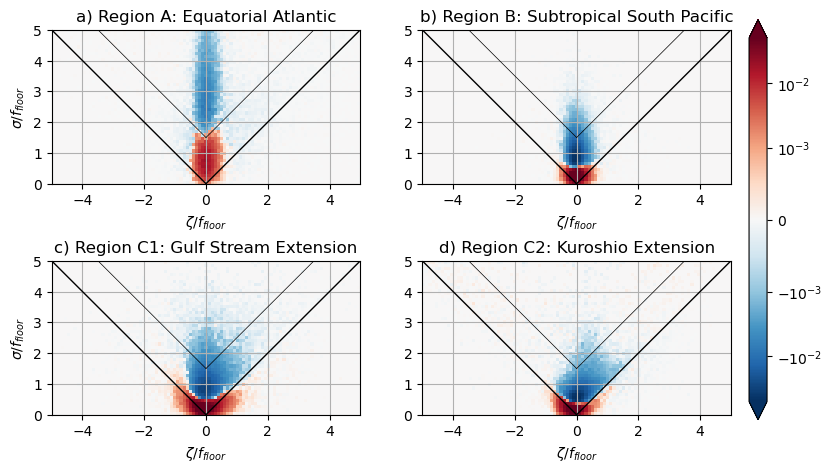

In [16]:
fig = plt.figure(figsize=(9, 5))

plt.subplot(221)
cs1=h_DivPdf_eq.plot.pcolormesh(x='vort_bin', vmax=0.05, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('a) Region A: Equatorial Atlantic')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')




plt.subplot(222)
cs1=h_DivPdf_sspac.plot.pcolormesh(x='vort_bin', vmax=0.05, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('b) Region B: Subtropical South Pacific')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('')


plt.subplot(223)
cs1=h_DivPdf_gs.plot.pcolormesh(x='vort_bin', vmax=0.05, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('c) Region C1: Gulf Stream Extension')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

plt.subplot(224)
cs1=h_DivPdf_ku.plot.pcolormesh(x='vort_bin', vmax=0.05, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('d) Region C2: Kuroshio Extension')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('')

plt.subplots_adjust(wspace=0.2,hspace=0.5,right=0.88)

cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.8])
fig.colorbar(cs1, cax=cbar_ax,extend='both')

plt.gcf().savefig('case-study-jpdfs.png')